# Assignment 6 - Object recognition in images with deep learning

## Goals

In this assignment you will get to know the main ingredients of deep learning and get to use the GPUs available in the Big Data Lab.

You'll learn to use

 * tensors and automatic differentiation
 * layered models
 * p(re)trained networks for image classification.

## Check the GPU setup

When you are logged in to a lab machine, run ``nvidia-smi`` to see the available card and its memory usage.

```
$ nvidia-smi
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.102.04   Driver Version: 450.102.04   CUDA Version: 11.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  GeForce GTX 105...  Off  | 00000000:01:00.0  On |                  N/A |
| 45%   24C    P8    N/A /  75W |   3087MiB /  4038MiB |      0%      Default |
+-------------------------------+----------------------+----------------------+
                                                                               
+-----------------------------------------------------------------------------+
| Processes:                                                       GPU Memory |
|  GPU       PID   Type   Process name                             Usage      |
|=============================================================================|
|    0      3627      G   /usr/lib/xorg/Xorg                           169MiB |
|    0     10843      C   ...d/CMPT/big-data/tmp_py/dlenv/bin/python  2897MiB |
+-----------------------------------------------------------------------------+
```

This shows that the machine has an **NVIDIA GTX 1050 with 4G of RAM**. Also, you can see that it is running a process (pid=10843) that currently takes up close to 3 GB of GPU memory. On our current lab machines you will notice a difference, as they may have different RAM sizes (refer to https://www.sfu.ca/fas/computing/support/csil/rdp-mpcs-workstations.html).

```
$ pstree -ls 10843
screen───bash───jupyter-noteboo───python─┬─4*[python]
                                         └─26*[{python}]
```
Inside a terminal window you may use ``who``, ``ps -aux | less``, or ``pstree -ls <PID>`` as above to find out who is using the shared resources. In my case, it turns out that I'm running a jupyter notebook related to process 10843. Halting the notebook frees up the GPU memory. 

## PyTorch setup in the lab

To build deep learning models in this assignment we are using **[PyTorch](http://pytorch.org)**, a replacement for numpy that provides accelerated computation on the GPU, automatic differentiation, and various utilities to train and deploy neural networks. Its popularity relative to [tensorflow](http://tensorflow.org) has been steadily increasing and it also has a high-level API, the [NN module](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html) similar to [tf.keras](https://www.tensorflow.org/api_docs/python/tf/keras).

In case you have trouble configuring a conda environment that has a CUDA version of pytorch installed, you could use the one that's provided under the prefix  
`conda activate /usr/shared/CMPT/big-data/condaenv/nn11a`

### Save disk space in the lab: Use shared downloaded pre-built models
To save disk space in your home folder, we recommend that you let pytorch use the pre-built models that we already downloaded for you (about 1.9G):
```
mkdir -p ~/.cache/torch/hub/checkpoints
ln -s /usr/shared/CMPT/big-data/dot_torch_shared/checkpoints/* ~/.cache/torch/hub/checkpoints
```

## Learn about Pytorch usage

To familiarize yourself with PyTorch, have a look at the [Examples](http://pytorch.org/tutorials/beginner/pytorch_with_examples.html) on Tensors, or the NN module, or briefly skim over the [60 min blitz tutorial](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html).

# Task 1: Finding rectangles

A nice [**blog-post** by Johannes Rieke](https://medium.com/data-science/object-detection-with-neural-networks-a4e2c46b4491) presents a simple setup from scratch that finds rectangles in a black & white image. In order to play with it, we just have to translate a few calls from Keras to PyTorch.

To familiarize yourself with using pytorch, have a look at the [Examples](http://pytorch.org/tutorials/beginner/pytorch_with_examples.html). The following code is preparing our training setup.

In [2]:
# to check GPU memory, uncomment and run the following line
!nvidia-smi

Fri Feb 27 21:35:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0 Off |                  Off |
|  0%   34C    P8              7W /  450W |      15MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The training data consists of $50,000$ example images.  
`imgs` is an array of shape (50000, 8, 8), giving an $8\times8$ pixel image for each example.  
`bboxes` is an array of shape (50000, 1, 4), giving a $1\times4$ row vector [x, y, w, h] for each rectangle.

**Here is an example of the training data:**

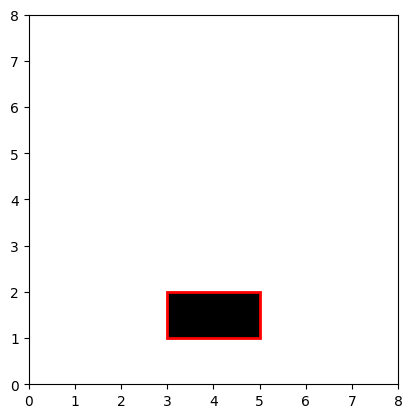

In [6]:
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib

# Create images with random rectangles and bounding boxes. 
num_imgs = 50000

img_size = 8
min_object_size = 1
max_object_size = 4
num_objects = 1

bboxes = np.zeros((num_imgs, num_objects, 4))
imgs = np.zeros((num_imgs, img_size, img_size))  # set background to 0

for i_img in range(num_imgs):
    for i_object in range(num_objects):
        w, h = np.random.randint(min_object_size, max_object_size, size=2)
        x = np.random.randint(0, img_size - w)
        y = np.random.randint(0, img_size - h)
        imgs[i_img, x:x+w, y:y+h] = 1.  # set rectangle to 1
        bboxes[i_img, i_object] = [x, y, w, h]

display(Markdown(f"The training data consists of ${num_imgs:,}$ example images.  \n"
                 f"`imgs` is an array of shape {imgs.shape}, giving an ${img_size}\\times{img_size}$ pixel image for each example.  \n"
                 f"`bboxes` is an array of shape {bboxes.shape}, giving a $1\\times4$ row vector [x, y, w, h] for each rectangle."
                ))
display(Markdown('**Here is an example of the training data:**'))
i = 0
plt.imshow(imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size])
for bbox in bboxes[i]:
    plt.gca().add_patch(matplotlib.patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], ec='r', fc='none', lw=2))

In [7]:
# Reshape and normalize the image data to mean 0 and std 1. 
X = (imgs.reshape(num_imgs, -1) - np.mean(imgs)) / np.std(imgs)
display(Markdown(f"New shape of `imgs`: {X.shape}, with normalized mean {np.mean(X):.2f} and stdev {np.std(X):.2f}"))

# Normalize x, y, w, h by img_size, so that all values are between 0 and 1.
# Important: Do not shift to negative values (e.g. by setting to mean 0), because the IOU calculation needs positive w and h.
y = bboxes.reshape(num_imgs, -1) / img_size
y.shape, np.mean(y), np.std(y)

# Split training and test.
i = int(0.8 * num_imgs)
train_X = X[:i]
test_X = X[i:]
train_y = y[:i]
test_y = y[i:]
test_imgs = imgs[i:]
test_bboxes = bboxes[i:]

New shape of `imgs`: (50000, 64), with normalized mean -0.00 and stdev 1.00

In [11]:
import torch

# Setting GPU (CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# numpy -> torch tensor (float32)
train_X_t = torch.tensor(train_X, dtype=torch.float32)
train_y_t = torch.tensor(train_y, dtype=torch.float32)
test_X_t  = torch.tensor(test_X,  dtype=torch.float32)
test_y_t  = torch.tensor(test_y,  dtype=torch.float32)

device: cuda


In [13]:
from torch.utils.data import DataLoader, TensorDataset

# Dataloader (Minibatch)
batch_size = 256
train_loader = DataLoader(
    TensorDataset(train_X_t, train_y_t),
    batch_size=batch_size,
    shuffle=True
)

## Task 1a
**Construct a Pytorch model that resembles the Keras one in the original blog post**, i.e. have a fully connected, hidden layer with 200 neurons, ReLU nonlinearity and dropout rate of 20%.

In [15]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(64, 512),     # 200 -> 512 
    nn.ReLU(),
    nn.Dropout(0.1),        # 0.2 -> 0.1 
    nn.Linear(512, 4)
).to(device)

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # Adadelta -> Adam
loss_fn = nn.MSELoss(reduction='mean')                      # more reliable

In [17]:
epochs = 200  # 30 -> 200
loss_record = []

model.train()
for epoch in range(epochs):
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    loss_record.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | train loss: {avg_loss:.6f}")

Epoch 20/200 | train loss: 0.000210
Epoch 40/200 | train loss: 0.000143
Epoch 60/200 | train loss: 0.000118
Epoch 80/200 | train loss: 0.000109
Epoch 100/200 | train loss: 0.000104
Epoch 120/200 | train loss: 0.000104
Epoch 140/200 | train loss: 0.000098
Epoch 160/200 | train loss: 0.000096
Epoch 180/200 | train loss: 0.000097
Epoch 200/200 | train loss: 0.000096


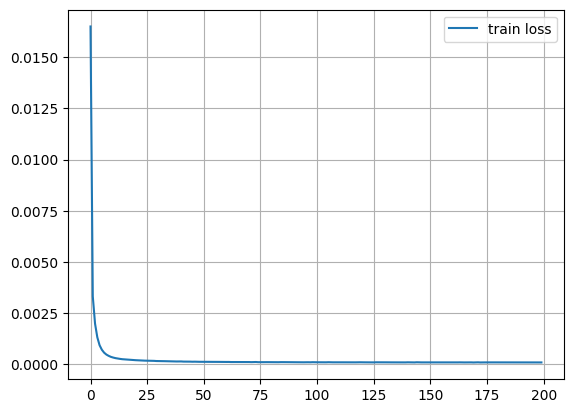

In [18]:
plt.plot(loss_record)
plt.legend(["train loss"])
plt.grid(True)
plt.show()

**Change the model from training to evaluation mode** to improve testing performance.

In [19]:
model.eval()
with torch.no_grad():
    pred_y = model(test_X_t.to(device)).cpu()   # GPU->CPU

pred_bboxes = (pred_y * img_size).numpy().reshape(len(test_X), num_objects, -1)

In [20]:
def IOU(bbox1, bbox2):
    '''Calculate overlap between two bounding boxes [x, y, w, h] as the area of intersection over the area of unity'''
    x1, y1, w1, h1 = bbox1[0], bbox1[1], bbox1[2], bbox1[3]
    x2, y2, w2, h2 = bbox2[0], bbox2[1], bbox2[2], bbox2[3]

    w_I = min(x1 + w1, x2 + w2) - max(x1, x2)
    h_I = min(y1 + h1, y2 + h2) - max(y1, y2)
    if w_I <= 0 or h_I <= 0:  # no overlap
        return 0.
    I = w_I * h_I
    U = w1 * h1 + w2 * h2 - I
    return I / U

np.float64(0.9135198398972274)

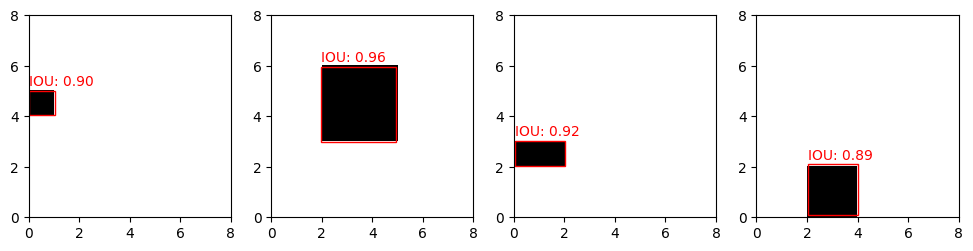

In [21]:
# Show a few images and predicted bounding boxes from the test dataset. 
plt.figure(figsize=(12, 3))
for i_subplot in range(1, 5):
    plt.subplot(1, 4, i_subplot)
    i = np.random.randint(len(test_imgs))
    plt.imshow(test_imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size])
    for pred_bbox, exp_bbox in zip(pred_bboxes[i], test_bboxes[i]):
        plt.gca().add_patch(matplotlib.patches.Rectangle((pred_bbox[0], pred_bbox[1]), pred_bbox[2], pred_bbox[3], ec='r', fc='none'))
        plt.annotate('IOU: {:.2f}'.format(IOU(pred_bbox, exp_bbox)), (pred_bbox[0], pred_bbox[1]+pred_bbox[3]+0.2), color='r')
# Calculate the mean IOU (overlap) between the predicted and expected bounding boxes on the test dataset. 
summed_IOU = 0.
for pred_bbox, test_bbox in zip(pred_bboxes.reshape(-1, 4), test_bboxes.reshape(-1, 4)):
    summed_IOU += IOU(pred_bbox, test_bbox)
mean_IOU = summed_IOU / len(pred_bboxes)
mean_IOU

## Task 1b:
Move the computation that is currently done on the CPU over to the GPU using CUDA and increase the number of epochs.  **Improve the training setup**, possibly also changing model or optimizer, until you **reach a test IOU above 0.9**.

You can make the changes that move computation to the GPU directly in the cells above as part of 1a.

You may get stuck not achieving test IOU above 0.6. In that case, learn about switching the model to evaluation mode and apply the change above.

## Question 1c:
Why does `eval` mode above have such a significant effect on test performance? Please give a short answer below.

eval() mode turns off Dropout during testing.
When Dropout is on, the model randomly disables some neurons, which makes predictions unstable and less accurate.
In eval() mode, all neurons are used, so the predictions become stable and test performance improves significantly.

# Task 2: Use a pretrained model

As mentioned in class, deep learning systems are hardly ever developed from scratch, but usually work by refining existing solutions to similar problems. For the following task, we'll **work through the 
[Transfer learning tutorial](http://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)**, which also provides a ready-made jupyter notebook.

 **2.1.** Download the notebook and get it to run in your environment. This also involves downloading the bees and ants dataset.  
 **2.2.** Perform your own training with the provided setup, fill out the answer to Task 2.2 below.  
 **2.3.** Change the currently chosen pretrained network (resnet) to a different one. At least try out VGG and one other type and use the "conv net as fixed feature extractor" approach, fill out the answer to Task 2.3 below.  
 **2.4.** Load a picture that you took yourself and classify it with an unmodified pretrained network (e.g. the original VGG network) that can detect one out of 1000 classes. Fill out the answer to Task 2.4 below.

## Your solution for Task 2

Before you start, get the data from [here](https://download.pytorch.org/tutorial/hymenoptera_data.zip) and extract it into a subfolder `data`. The following import is going to attempt loading the image data from there.

Initialize much of the source code from the tutorial notebook located at
https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
using the `tfl_tut` module provided.

In [23]:
from tfl_tut import *

Please study the original notebook and then continue to use its functions as imported from the `tfl_tut` model for convenience to minimize source code copy & paste.

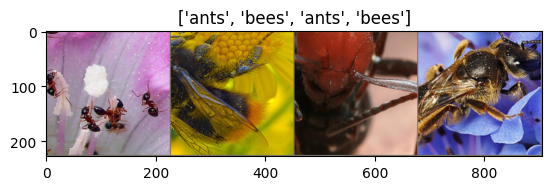

In [24]:
# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [25]:
model_conv = models.inception_v3(pretrained=True)

/home/jpa229/Downloads/A6-20260228T050017Z-1-001/A6/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jpa229/Downloads/A6-20260228T050017Z-1-001/A6/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/jpa229/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100.0%


### Answer for Task 2.2

In [26]:
# Load a pretrained ResNet18 model (already trained on ImageNet)
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# Get number of input features to the final fully connected layer
num_ftrs = model_ft.fc.in_features

# Replace the final layer to output 2 classes (ants and bees)
model_ft.fc = nn.Linear(num_ftrs, 2)

# Move model to GPU if available
model_ft = model_ft.to(device)

# Define loss function for classification
criterion = nn.CrossEntropyLoss()

# Use SGD optimizer to update all model parameters
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Reduce learning rate by 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

6.7%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jpa229/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


In [27]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5978 Acc: 0.6803
val Loss: 0.2121 Acc: 0.9020

Epoch 1/24
----------
train Loss: 0.5389 Acc: 0.7623
val Loss: 0.1836 Acc: 0.9346

Epoch 2/24
----------
train Loss: 0.4427 Acc: 0.8443
val Loss: 0.2529 Acc: 0.9150

Epoch 3/24
----------
train Loss: 0.3739 Acc: 0.8607
val Loss: 0.2472 Acc: 0.9216

Epoch 4/24
----------
train Loss: 0.5410 Acc: 0.7664
val Loss: 0.3083 Acc: 0.8954

Epoch 5/24
----------
train Loss: 0.3569 Acc: 0.8525
val Loss: 0.2292 Acc: 0.9346

Epoch 6/24
----------
train Loss: 0.4044 Acc: 0.8566
val Loss: 0.3680 Acc: 0.8889

Epoch 7/24
----------
train Loss: 0.3145 Acc: 0.8566
val Loss: 0.2402 Acc: 0.9085

Epoch 8/24
----------
train Loss: 0.2526 Acc: 0.8811
val Loss: 0.2312 Acc: 0.9150

Epoch 9/24
----------
train Loss: 0.2608 Acc: 0.8852
val Loss: 0.2299 Acc: 0.9150

Epoch 10/24
----------
train Loss: 0.2777 Acc: 0.8852
val Loss: 0.2739 Acc: 0.8954

Epoch 11/24
----------
train Loss: 0.2599 Acc: 0.8852
val Loss: 0.2101 Acc: 0.9281

Ep

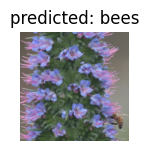

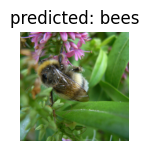

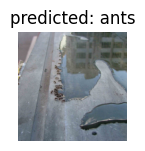

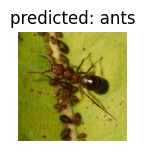

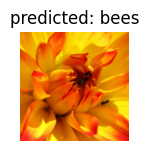

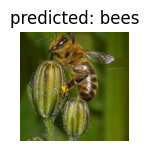

In [28]:
visualize_model(model_ft)

### Answer for Task 2.3

### Hints for this task

Focus on the section **Conv net as fixed feature xtractor** of the transfer learning tutorial.
First, change the line
```
model_conv = models.resnet18(pretrained=True)
```
to load VGG16 instead. Set all its parameters to *not* require gradient computation, as shown in the tutorial.

Next, print out the new `model_conv` and identify the last step of the classification. This is not named the same way as the ```fc``` layer for resnet, but it works similarily. The last classification step of the VGG model determines the probabilities for each of the 1000 classes of the dataset. Change this layer to identify only 2 classes to distinguish ants and bees as in the example.

To change the structure of some `Sequential` component called ```model_conv.module_name``` and to modify its last layer into a `DifferentLayer` type, you can use this syntax:

```
nn.Sequential(*list(model_conv.module_name.children())[:-1] +
                     [nn.DifferentLayer(...)])
```
and replace the old `model_conv.module_name` with this differently structured version.

0.2%

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/jpa229/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

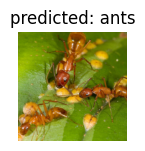

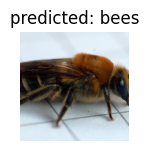

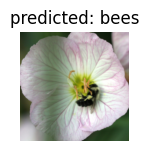

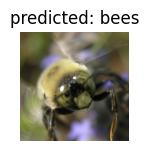

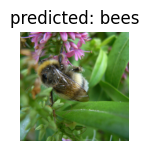

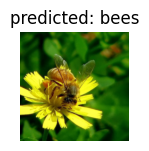

In [29]:
# Load pretrained VGG16
model_conv_vgg = torchvision.models.vgg16(weights='IMAGENET1K_V1')

print(model_conv_vgg)
print(model_conv_vgg.classifier)

# Freeze all parameters (fixed feature extractor)
for param in model_conv_vgg.parameters():
    param.requires_grad = False

# Replace the LAST classification layer: 1000 -> 2
# VGG has model_conv.classifier (a Sequential)
# The last layer is classifier[6]
num_ftrs = model_conv_vgg.classifier[6].in_features
model_conv_vgg.classifier[6] = nn.Linear(num_ftrs, 2)

model_conv_vgg = model_conv_vgg.to(device)

# Loss
criterion = nn.CrossEntropyLoss()

# Optimize ONLY the new last layer
optimizer_conv_vgg = optim.SGD(model_conv_vgg.classifier[6].parameters(), lr=0.001, momentum=0.9)

# LR scheduler
exp_lr_scheduler_vgg = lr_scheduler.StepLR(optimizer_conv_vgg, step_size=7, gamma=0.1)

# Train
model_ft_vgg = train_model(model_conv_vgg, criterion, optimizer_conv_vgg, exp_lr_scheduler_vgg, num_epochs=25)

# Visualize
visualize_model(model_conv_vgg)

plt.ioff()
plt.show()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/jpa229/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100.0%


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

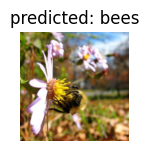

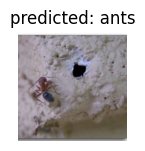

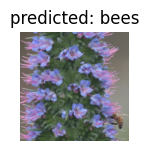

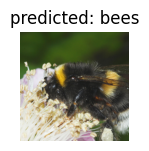

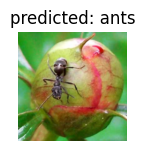

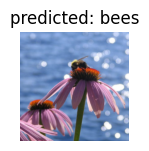

In [30]:
# Load pretrained DenseNet121
model_conv_dense = torchvision.models.densenet121(weights='IMAGENET1K_V1')

print(model_conv_dense)
print("Classifier:", model_conv_dense.classifier)  # DenseNet은 classifier가 1개 Linear임

# Freeze all parameters
for param in model_conv_dense.parameters():
    param.requires_grad = False

# Replace final classifier: 1000 -> 2
num_ftrs = model_conv_dense.classifier.in_features
model_conv_dense.classifier = nn.Linear(num_ftrs, 2)

model_conv_dense = model_conv_dense.to(device)

# Loss
criterion = nn.CrossEntropyLoss()

# Optimize ONLY the new classifier
optimizer_conv_dense = optim.SGD(model_conv_dense.classifier.parameters(), lr=0.001, momentum=0.9)

# LR scheduler
exp_lr_scheduler_dense = lr_scheduler.StepLR(optimizer_conv_dense, step_size=7, gamma=0.1)

# Train
model_dense = train_model(model_conv_dense, criterion, optimizer_conv_dense,
                          exp_lr_scheduler_dense, num_epochs=25)

# Visualize
visualize_model(model_dense)

plt.ioff()
plt.show()

### Answer for Task 2.4

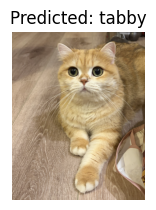

In [31]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision.models import VGG16_Weights

def visualize_imagenet_prediction(model, img_path):
    was_training = model.training
    model.eval()

    # Load image
    img = Image.open(img_path).convert("RGB")

    # ImageNet preprocessing
    weights = VGG16_Weights.IMAGENET1K_V1
    preprocess = weights.transforms()
    img = preprocess(img)

    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        # ImageNet 1000 labels
        labels = weights.meta["categories"]

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {labels[preds[0]]}')
        plt.imshow(Image.open(img_path))
    
    model.train(mode=was_training)


# ---- Load UNMODIFIED pretrained VGG16 ----
weights = VGG16_Weights.IMAGENET1K_V1
model_imagenet = torchvision.models.vgg16(weights=weights)
model_imagenet = model_imagenet.to(device)

# ---- Use your own photo here ----
visualize_imagenet_prediction(
    model_imagenet,
    img_path="example.png"
)

plt.ioff()
plt.show()

Please include the picture so we can view it and its class label in the saved notebook. It's OK, if we don't have the actual image file to reproduce the output.

## Submission

Your submission should be based on a modified version of this notebook containing answers to Task 1 and for Task 2, saved with figures including some portions of the transfer learning tutorial notebook in the sections for tasks 2.1 - 2.4.